##### *Import all necessary packages*

In [1]:
import scvi
import numpy as np
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import scanpy as sc
from scipy.stats import pearsonr, spearmanr, ttest_ind
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list, optimal_leaf_ordering
from scipy.spatial.distance import squareform
from adjustText import adjust_text
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)
# add current path to sys.path
import sys
import os
PWD = os.getcwd()
sys.path.append(f'{PWD}')
from utils import STARRFISH
import re
import statsmodels.api as sm
from statsmodels.stats import multitest

Seed set to 0


Last run with scvi-tools version: 1.3.1.post1


##### *Load STARR-FISH data for preprocessing and statistical analysis*

###### Load in custom colors

In [ ]:
# Load in custom colors for the 24 cell types used in downstream analysis

import json

with open('subclass_colors.json', 'r') as f:
    subclass_colors = json.load(f)

subclass_colors = {k.replace('/', '-'): v for k, v in subclass_colors.items()}

###### Preprocess and load the STARR-FISH data using custom code (starrfish)

In [2]:
# preprocess and load data
def reload(starrfish):
    import importlib
    import utils
    importlib.reload(utils)
    from utils import STARRFISH
    starrfish.__class__ = STARRFISH
    return starrfish

def drop_test(starrfish, test_method):
    if hasattr(starrfish, f'{test_method}_configs'):
        delattr(starrfish, f'{test_method}_configs')
    if hasattr(starrfish, f'{test_method}_results'):
        delattr(starrfish, f'{test_method}_results')
    return starrfish

def preprocess(adata_path):
    adata = sc.read_h5ad(adata_path)
    # operate fov, it is the index names
    adata.obs['fov'] = adata.obs.index.str.split('--').str[0]
    # change adata2 obs subclass_name to subclass
    adata.obs['subclass'] = adata.obs['subclass_name'].str.replace('^[0-9]+ ', '', regex=True)
    # change '' best_subclass to its label
    adata.uns['CRE_info']['best_subclass'][adata.uns['CRE_info']['best_subclass'] == ''] = adata.uns['CRE_info']['label'][adata.uns['CRE_info']['best_subclass'] == ''].copy()
    # process enh
    chrom = []
    start = []
    end = []
    for i in adata.uns['CRE_info']['enh']:
        if i.startswith('chr'):
            chrom.append(i.split(':')[0])
            start.append(int(re.split('−|-', i.split(':')[1])[0]))
            end.append(int(re.split('−|-', i.split(':')[1])[1]))
        else:
            chrom.append(i)
            start.append('')
            end.append('')
    adata.uns['CRE_info']['Chrom'] = chrom
    adata.uns['CRE_info']['Start'] = start
    adata.uns['CRE_info']['End'] = end
    # convert start and end to str
    adata.uns['CRE_info']['Chrom'] = adata.uns['CRE_info']['Chrom'].astype(str)
    adata.uns['CRE_info']['Start'] = adata.uns['CRE_info']['Start'].astype(str)
    adata.uns['CRE_info']['End'] = adata.uns['CRE_info']['End'].astype(str)
    # rename enh
    adata.uns['CRE_info']['enh'] = adata.uns['CRE_info']['Chrom'] + ':' + adata.uns['CRE_info']['Start'].astype(str) + '-' + adata.uns['CRE_info']['End'].astype(str)
    # rename best_subclass
    adata.uns['CRE_info']['best_subclass'] = adata.uns['CRE_info']['best_subclass'].str.replace('_', ' ')
    adata.uns['CRE_info'].index = ['CRE' + str(i+1).zfill(3) for i in range(len(adata.uns['CRE_info']))]
    adata.obsm['CRE'] = adata.obsm['CRE'][adata.uns['CRE_info'].index]
    return adata

In [3]:
# load data and form STARRFISH object
load = True
if not load:
    adata2 = preprocess(f'{PWD}\starrfish2_filtered.pkl_adata.h5ad')
adata_cpm = 'ATAC_cpm_peakBysubclass.csv'
if os.path.exists('results\starrfish2_filtered.pkl') and load:
    starrfish2_filtered = STARRFISH.load('results\starrfish2_filtered.pkl')
else:
    starrfish2_filtered = STARRFISH(adata2[(adata2.obsm['CRE'] > 0).sum(axis=1) > 0], atac_cpm=adata_cpm)

###### Calculate fold change and FDR for cell type-specific cCRE activity

In [4]:
# define CREs to use
lib_size = starrfish2_filtered.lib_size['counts']
# fold to average lib_size
lib_size_fold = lib_size / lib_size.mean()
# remove CREs with less than 5 fold enrichment
cres_to_use_libsize_high = lib_size_fold[lib_size_fold > 1/40].index
# remove CRE217
cres_to_use_libsize_high = cres_to_use_libsize_high[cres_to_use_libsize_high != 'CRE217']
non_negative_control_cres = lib_size.index[~lib_size.index.isin(starrfish2_filtered.get_negative_control_cres())]
len(cres_to_use_libsize_high), lib_size.loc[cres_to_use_libsize_high].min()
# define cell types to use for filtered data
cell_types_counts2 = starrfish2_filtered.get_celltypes().value_counts()
cell_types_to_use_2 = cell_types_counts2[cell_types_counts2 > 500].index
# check the negative control counts for those cell types
negative_control_counts2 = starrfish2_filtered.get_cre_expression()[starrfish2_filtered.get_negative_control_cres()].sum(axis=1).groupby(starrfish2_filtered.get_celltypes()).sum()
# define the cell types by the negative control counts > 50
cell_types_to_use_nc_2 = negative_control_counts2[negative_control_counts2 > 40].index
target_cres = starrfish2_filtered.get_creinfo().index[starrfish2_filtered.get_creinfo()['best_subclass'].isin(cell_types_to_use_nc_2)]
len(cell_types_to_use_nc_2), len(target_cres)

(24, 50)

In [5]:
# get the p-value only in those cell types
fold_change_test_config = {"cell_types_to_use": cell_types_to_use_nc_2.to_list(),
                           "normalize_by_cell_rna": False,
                           "normalize_by_cell_volume": False,
                           "normalize_by_celltype_rna": False,
                           "normalize_by_celltype_volume": False,
                           "normalize_by_negative_control": True,
                           "normalize_by_infected_cell": False,
                           "normalize_by_libsize": False,
                           "log_transform": False,
                           "rank_transform": None,
                           "filter_zero_counts": False,
                           "bootstrap_number": 5000,
                           'n_jobs': 256}
res2 = starrfish2_filtered.fold_change_test(**fold_change_test_config)
# for each CRE, do q-value correction
res2_q = res2['qvalue_activity'].copy()
target_df = pd.DataFrame(index=res2_q.columns, columns=['on-target', 'off-target', 'best_subclass'])
for cre in res2_q.columns:
    # get on-target cell types
    target_celltypes = starrfish2_filtered.get_creinfo().loc[cre, 'best_subclass']
    if isinstance(target_celltypes, str):
        target_celltypes = [target_celltypes]
    target_df.loc[cre, 'on-target'] = res2_q.index[res2_q[cre] <= 0.05].isin(target_celltypes).sum()
    target_df.loc[cre, 'off-target'] = len(res2_q.index[res2_q[cre] <= 0.05]) - target_df.loc[cre, 'on-target']
    target_df.loc[cre, 'best_subclass'] = target_celltypes
print(target_df['on-target'].sum(), (target_df['off-target'] > 0).sum(), ((target_df['off-target']==0) & (target_df['on-target'] > 0)).sum())

Results already exist, return stored results
9 164 3


##### *Plot the spatial activity of individual cCREs along with the enriched target cell types*

In [155]:
starrfish2_filtered.adata.obs['subclass_trimmed'] = starrfish2_filtered.adata.obs['subclass_name'].str.slice(start=4)

###### Define functions for plotting cCRE activity and target cell types

In [366]:
def plot_cluster_scdata(scdata, clusters=['Endo NN'], use='subclass', 
                        transpose=1, flipx=1, flipy=1, sbig=30, small=5, 
                        x_region=None, y_region=None, cmap=None,
                        ax=None, plot_legend = False, tag='X_spatial',
                        figsize=(20,10)):
    Xcells = scdata.obsm[tag][:, ::transpose] * [flipx, flipy]
    if cmap is None:
        cmap = scdata.uns['cmap']
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, facecolor="black")
        toreturn = True
    else:
        fig = ax.figure
        toreturn = False
    x = Xcells[:, 0]
    y = Xcells[:, 1]
    x_ = x.copy()
    y_ = y.copy()
    if x_region is not None:
        select_region = (x_ > x_region[0]) & (x_ < x_region[1])
        x_ = x_[select_region]
        y_ = y_[select_region]
    if y_region is not None:
        select_region = (y_ > y_region[0]) & (y_ < y_region[1])
        x_ = x_[select_region]
        y_ = y_[select_region]
    plt.scatter(x_, y_, c='gray', s=3, alpha=0.7, marker='.', rasterized=True, edgecolors='none')
    for i, cluster in enumerate(clusters):
        cluster_ = str(cluster)
        inds = scdata.obs[use] == cluster_
        x_ = x[inds]
        y_ = y[inds]
        col = cmap[cluster_]
        if x_region is not None:
            select_region = (x_ > x_region[0]) & (x_ < x_region[1])
            x_ = x_[select_region]
            y_ = y_[select_region]
        if y_region is not None:
            select_region = (y_ > y_region[0]) & (y_ < y_region[1])
            x_ = x_[select_region]
            y_ = y_[select_region]
        ax.scatter(x_, y_, c=col, s=sbig, marker='.',label = cluster_, rasterized=True, edgecolors='none')
    
    # if cluster len is 1, then plot title
    # ax.set_title(f"Cell types", color='white', fontsize=20)
    if plot_legend:
        # if cluster len larger than 5, plot it outside
        if len(clusters) > 5:
            ax.legend(fontsize=20, loc='upper left', bbox_to_anchor=(1.05, 1))
        else:
            ax.legend(fontsize=20, loc='lower right')
    # Format axes
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    if toreturn:
        fig.tight_layout()
        plt.close(fig)
        return fig

In [543]:
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap


def plot_gene(self, gene='CRE129', use='CRE', 
                  average_by_celltype=False, 
                  norm_by_negative_control_cell_type_mean=False, norm_by_negative_control_cell_type_sum=True, 
                  norm_by_negative_control_single_cell=False, log=True,
                  cell_types_to_use=None, cell_types_to_visualize=None, 
                  nmin=None, nmax=None, sz_min=5, sz_max=30, scale_size_by = 'counts',  
                  cmap_name='Reds', show_scalebar=True, show_title=True,
                  x_region=None, y_region=None, select_region_by_best_celltype=False, show_celltypes=True,
                  transpose=1, flipx=1, flipy=1, smooth_k=None, figsize=(30, 10)):
        tag = self.spatial_tag.split(':')[1]
        Xcells = self.adata.obsm[tag][:, ::transpose] * [flipx, flipy]
        # get best cell type
        if use == 'CRE':
            if cell_types_to_visualize is None:
                best_celltype = [self.adata.uns['CRE_info'].loc[gene, 'best_subclass']]
            else:
                best_celltype = list(cell_types_to_visualize)
        # Get expression data
        if use == 'X':
            gene_idx = list(self.adata.var.index).index(gene)
            cts = self.adata.X[:, gene_idx].copy()
        else:
            cts = self.adata.obsm[use][gene].copy()
        # if average_by_celltype, then average by cell type
        if average_by_celltype:
            # get the cell types
            cell_type_cts = cts.groupby(self.get_celltypes()).mean()
            cts = cell_type_cts.loc[self.get_celltypes()].copy()
            # rename the index
            cts.index = self.get_celltypes().index
        # if norm_by_negative_control, then normalize by negative control
        if norm_by_negative_control_cell_type_mean:
            negative_control_counts = self.get_cre_expression()[self.get_negative_control_cres()].sum(axis=1).groupby(self.get_celltypes()).mean()
            norm_factor = negative_control_counts.loc[self.get_celltypes()]
            cts = cts / norm_factor.values
        if norm_by_negative_control_cell_type_sum:
            negative_control_counts = self.get_cre_expression()[self.get_negative_control_cres()].sum(axis=1).groupby(self.get_celltypes()).sum()
            norm_factor = negative_control_counts.loc[self.get_celltypes()]
            cts = cts / norm_factor.values
        if norm_by_negative_control_single_cell:
            negative_control_counts = self.get_cre_expression()[self.get_negative_control_cres()].sum(axis=1)
            cts = cts / negative_control_counts.values
        if log:
            cts = np.log1p(cts)
        if cell_types_to_use is not None:
            # only cts for the cell types to use
            cts[~self.get_celltypes().isin(cell_types_to_use)] = np.nan
        # Prepare plot parameters
        cts = np.nan_to_num(cts, nan=0, posinf=0, neginf=0)
        # if smoothing_k is not None, then smooth the data spatially by k-nearest neighbors
        if smooth_k is not None:
            # get the k nearest neighbors
            knn = NearestNeighbors(n_neighbors=smooth_k, algorithm='ball_tree').fit(Xcells)
            _, indices = knn.kneighbors(Xcells)
            # smooth the data
            cts = np.nanmean(cts[indices], axis=1)
        # filter out nmin
        if nmin is not None:
            cts[cts < nmin] = 0
        nmax = np.nanmax(cts) if nmax is None else nmax
        ncts = np.clip(cts/nmax, 0, 1)

        if scale_size_by == 'counts':
            # size = sz_min + ncts * (sz_max - sz_min)
            # size = ncts
            scaler = MinMaxScaler(feature_range=(0, 1))
            scaled_sizes = scaler.fit_transform(ncts.reshape(-1,1)).flatten()
            emphasized_sizes = scaled_sizes ** 3  # Try 2, 3, or 0.5 for different effects
            size = sz_min + (sz_max - sz_min) * emphasized_sizes

        elif scale_size_by == 'celltype_number':
            # get the number of cell types
            celltype_number = self.get_celltypes().value_counts().loc[self.get_celltypes()].values
            # if not in cell_types_to_use, then set to 0
            celltype_number[~self.get_celltypes().isin(cell_types_to_use)] = 0
            # normalize the celltype_number
            celltype_number = celltype_number.max() - celltype_number + 1
            celltype_number = np.clip(celltype_number / celltype_number.max(), 0, 1)
            size = sz_min + celltype_number * (sz_max - sz_min)

        # Define custom colormap: gray -> bright green
        gray_to_green = LinearSegmentedColormap.from_list("gray_to_green", ["gray", "#00FF00"])
        cmap = gray_to_green(ncts)

        cmap = plt.get_cmap(cmap_name)(ncts)
        if select_region_by_best_celltype:
            # select region by best_celltype
            xmin = Xcells[:, 0].min()
            xmax = Xcells[:, 0].max()
            ymin = Xcells[:, 1].min()
            ymax = Xcells[:, 1].max()
            for celltype in best_celltype:
                # get the cell type
                celltype_idx = self.get_celltypes() == celltype
                # get the coordinates of the cells
                x_min = Xcells[celltype_idx, 0].min()
                x_max = Xcells[celltype_idx, 0].max()
                y_min = Xcells[celltype_idx, 1].min()
                y_max = Xcells[celltype_idx, 1].max()
                # select the region
                if x_min > xmin:
                    xmin = x_min
                if x_max < xmax:
                    xmax = x_max
                if y_min > ymin:
                    ymin = y_min
                if y_max < ymax:
                    ymax = y_max
            x_region = (xmin, xmax)
            y_region = (ymin, ymax)
        if x_region is not None:
            select_region = (Xcells[:, 0] > x_region[0]) & (Xcells[:, 0] < x_region[1])
            Xcells = Xcells[select_region]
            cts = cts[select_region]
            cmap = cmap[select_region]
            size = size[select_region]
        if y_region is not None:
            select_region = (Xcells[:, 1] > y_region[0]) & (Xcells[:, 1] < y_region[1])
            Xcells = Xcells[select_region]
            cts = cts[select_region]
            cmap = cmap[select_region]
            size = size[select_region]
        # Create single figure and axes
        if use == 'CRE':
            if show_celltypes:
                fig = plt.figure(figsize=figsize, facecolor='k')
                gs = fig.add_gridspec(1, 3, width_ratios=[0.49, 0.02, 0.49], wspace=0.05)
                ax_main = fig.add_subplot(gs[0])
                # ax_cbar = fig.add_subplot(gs[1])

                ax_cbar = inset_axes(
                            ax_main,
                            width="15%",  # Width of inset
                            height="40%",  # Height of inset
                            loc='upper right',  # Position inside ax_main
                            bbox_to_anchor=(0, 0, 0.9, 1.5),
                            bbox_transform=ax_main.transAxes,
                            borderpad=1
                        )

                ax_ctypes = fig.add_subplot(gs[2])
                plot_cluster_scdata(self.adata, clusters=best_celltype, use='subclass', 
                                    transpose=transpose, flipx=flipx, flipy=flipy, 
                                    x_region=x_region, y_region=y_region, cmap=subclass_colors,
                                    sbig=20, small=3, ax=ax_ctypes, plot_legend=True)
            else:
                gs = fig.add_gridspec(1, 3, width_ratios=[0.95, 0.05], wspace=0.05)
                ax_main = fig.add_subplot(gs[0])
                ax_cbar = fig.add_subplot(gs[1])

            if show_title:
                ax_main.set_title(f'{gene}', color='white', fontsize=20)
            ax_main.set_facecolor('black')
            
            # Plot data
            cell_with_genes = np.where(cts > 0)[0]
            # first plot cells without genes, then plot cells with genes
            ax_main.scatter(Xcells[:, 0], Xcells[:, 1], c='grey', s=3, marker='.', alpha=0.7, rasterized=True, edgecolors='none')
            # scale the alpha values for the points based on counts
            scaler = MinMaxScaler(feature_range=(0, 1))
            scaled_alpha = scaler.fit_transform(ncts.reshape(-1,1)).flatten()
            # plot the CRE counts
            # ax_main.scatter(Xcells[cell_with_genes, 0], Xcells[cell_with_genes, 1], c='#00FF00', sizes=size[cell_with_genes], alpha=scaled_alpha[cell_with_genes], rasterized=True)
            ax_main.scatter(Xcells[:, 0], Xcells[:, 1], c='#00FF00', sizes=size, alpha=scaled_alpha, rasterized=True, edgecolors='none')

            # Format axes
            ax_main.grid(False)
            ax_main.set_xticks([])
            ax_main.set_yticks([])
            ax_main.set_aspect('equal')
            
            # Set colorbar axis background
            ax_cbar.set_facecolor('black')

            if show_scalebar:
                # Create colorbar in the dedicated axis
                # sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap_name), norm=plt.Normalize(vmin=0, vmax=nmax))
                # cbar = plt.colorbar(
                #     sm,
                #     cax=ax_cbar,  # Use dedicated axis
                #     orientation='vertical',
                #     shrink=0.1          # Scale height of colorbar (0.8 = 80% of plot height)
                # )

                # Custom size/alpha scale bar
                ax_cbar.set_facecolor('black')
                ax_cbar.axis('off')

                # Define scale bar points
                legend_vals = np.linspace(0, 1.0, 7)  # Normalized from 0 to 1
                legend_cts = legend_vals * nmax

                # Reuse the size and alpha scaling from main plot
                legend_scaled_sizes = legend_vals ** 3  # Same emphasis
                legend_sizes = sz_min + (sz_max - sz_min) * legend_scaled_sizes
                legend_alphas = legend_vals  # Directly scale alpha from value

                # Plot circles in ax_cbar
                dot_spacing = 0.15  # smaller = tighter packing
                for i, (val, sz, alpha) in enumerate(zip(legend_cts, legend_sizes, legend_alphas)):
                    x = i * dot_spacing
                    ax_cbar.scatter(x, 0.25, s=sz, alpha=alpha, color='#00FF00', edgecolors='none')

                # Add only min and max labels
                ax_cbar.text(-0.6, 0.25, f'{legend_cts[0]:.2f}', va='center', ha='center', color='white', fontsize=12)
                ax_cbar.text(1.4, 0.25, f'{legend_cts[-1]:.2f}', va='center', ha='center', color='white', fontsize=12)


                # ax_cbar.set_ylim(-0.5, (len(legend_cts)-1) * dot_spacing + 0.5)

                # Set limits and aesthetics
                ax_cbar.set_xlim(0, 2)
                ax_cbar.set_xlim(-0.5, (len(legend_cts)-1) * dot_spacing + 0.5)
                ax_cbar.set_ylim(0, 1.5)  # Enough vertical space for dots + labels
                # ax_cbar.set_ylim(-0.5, len(legend_cts) - 0.5)
                ax_cbar.text(0.5 * (len(legend_cts)-1) * dot_spacing, 0.4, 'Normalized Counts',
                ha='center', va='top', color='white', fontsize=12)

                # Format colorbar
                # cbar.set_label('Normalized Counts', color='white', fontsize=16)
                # cbar.ax.yaxis.set_tick_params(color='white')
                # cbar.ax.tick_params(labelcolor='white', labelsize=10)
                # cbar.ax.set_yticks(np.linspace(0, nmax, 5))
                # cbar.ax.set_yticklabels([f'{i:.2f}' for i in np.linspace(0, nmax, 5)], color='white')

                # Remove axis spines from colorbar
                ax_cbar.spines['top'].set_visible(False)
                ax_cbar.spines['right'].set_visible(False)
                ax_cbar.spines['bottom'].set_visible(False)
                ax_cbar.spines['left'].set_visible(False)

        else:
            fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
            ax.set_title(f'{gene} - N max {nmax}', color='white')
            ax.set_facecolor('black')
            
            # Plot data
            XC = -Xcells[:, ::-1]
            cell_with_genes = np.where(cts > 0)[0]
            # first plot cells without genes, then plot cells with genes
            ax.scatter(XC[:, 0], XC[:, 1], c='grey', s=sz_min, marker='.', rasterized=True)
            # ax.scatter(XC[~cell_with_genes, 0], XC[~cell_with_genes, 1], c=cmap[~cell_with_genes], s=size[~cell_with_genes])
            ax.scatter(XC[cell_with_genes, 0], XC[cell_with_genes, 1], c='#00FF00', s=sz_max, rasterized=True)
            # c=cmap[cell_with_genes]
            
            # Format axes
            ax.grid(False)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect('equal')
        
        fig.tight_layout()
        plt.close(fig)
        return fig

###### Plot the data and save figures

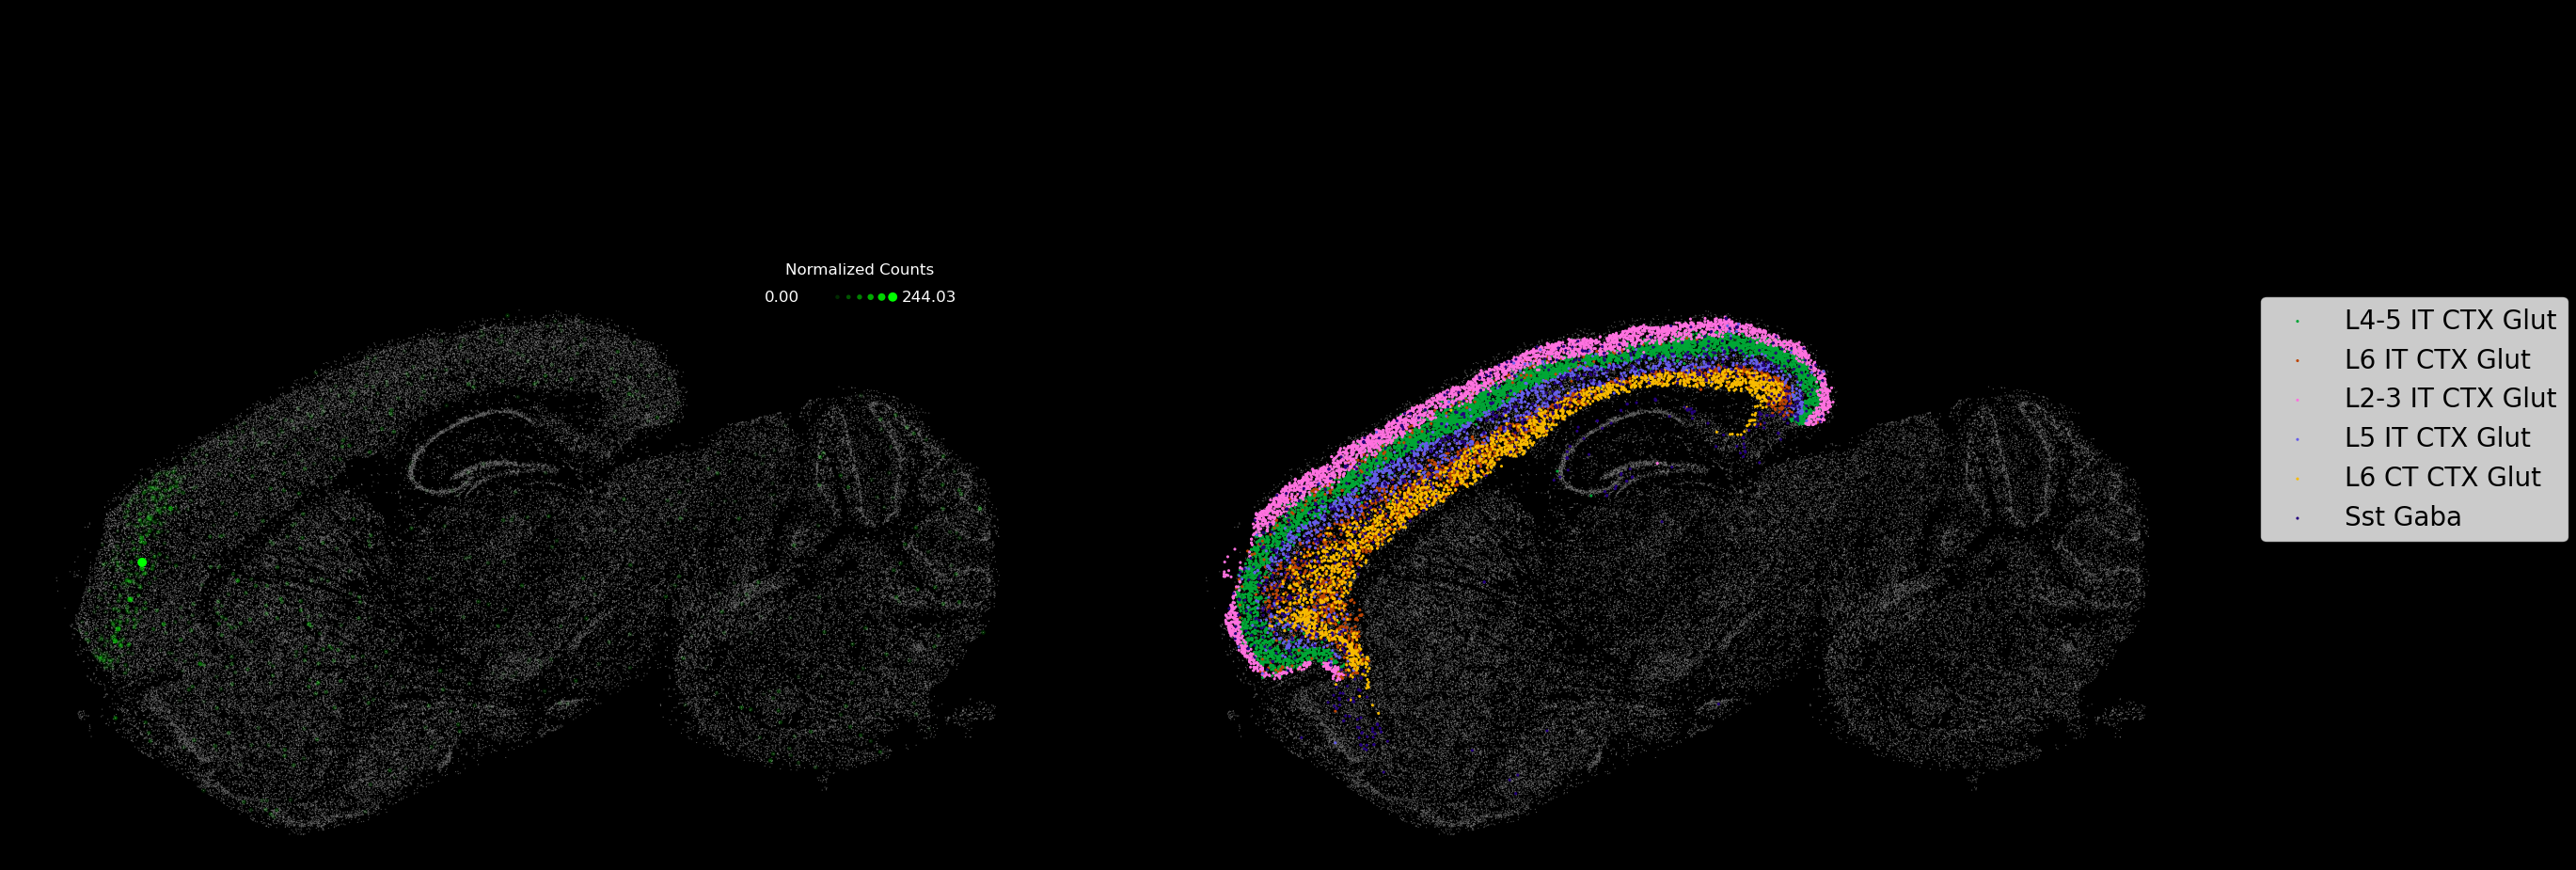

In [575]:
from utils import STARRFISH

cre = 'CRE229'

# rank by q-value
cre_q_values = res2['qvalue_activity'].loc[cell_types_to_use_nc_2, cre]
cre_q_values = cre_q_values[cre_q_values <= 0.05] 
# order by rank
cre_q_values = cre_q_values.sort_values(ascending=True)
cell_types_to_visualize = cre_q_values.index

fig = plot_gene(starrfish2_filtered,
    cre, average_by_celltype=False, # if true, all cells from same cell type will have same value
    norm_by_negative_control_cell_type_sum=False, # normalize raw counts by the sum of negative control in the cell type
    norm_by_negative_control_cell_type_mean=True, # normalize raw counts by the mean of negative control in the cell type
    norm_by_negative_control_single_cell=False, # normalize raw counts by the negative control in each single cell
    cell_types_to_visualize=cell_types_to_visualize, # only visualize some cell types
    scale_size_by='counts', # scale size by "counts": normalized counts; or "celltype_number": number of cells in the cell type
    log=False, transpose=-1, flipx=-1, sz_min=10,sz_max=50, nmax=None,
    cell_types_to_use=cell_types_to_use_nc_2,
    show_title=False, show_scalebar=True)

fig
# fig.savefig(rf'C:\Users\zgibbs\STARR-FISH\figures\STARR-FISH_ms_figure_3\CRE_activity_spatial_plots\{cre}.pdf')
# fig.savefig(rf'C:\Users\zgibbs\STARR-FISH\figures\STARR-FISH_ms_figure_3\CRE_activity_spatial_plots\{cre}.png', dpi=500)


##### *Plot total cCRE activity across the brain*

###### Define new function for plotting total cCRE activity

In [348]:
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap


def plot_all_cres(self, gene='CRE129', use='CRE', 
                  average_by_celltype=False, 
                  norm_by_negative_control_cell_type_mean=False, norm_by_negative_control_cell_type_sum=True, 
                  norm_by_negative_control_single_cell=False, log=True,
                  cell_types_to_use=None, cell_types_to_visualize=None, show_title=True,
                  nmin=None, nmax=None, sz_min=5, sz_max=30, scale_size_by = 'counts',  
                  cmap_name='Reds', show_scale_bar=True,
                  x_region=None, y_region=None, select_region_by_best_celltype=False, show_celltypes=True,
                  transpose=1, flipx=1, flipy=1, smooth_k=None, figsize=(30, 10)):
        tag = self.spatial_tag.split(':')[1]
        Xcells = self.adata.obsm[tag][:, ::transpose] * [flipx, flipy]
        # get best cell type
        if use == 'CRE':
            if cell_types_to_visualize is None:
                best_celltype = [self.adata.uns['CRE_info'].loc[gene, 'best_subclass']]
            else:
                best_celltype = list(cell_types_to_visualize)
        # Get expression data
        if use == 'X':
            gene_idx = list(self.adata.var.index).index(gene)
            cts = self.adata.X[:, gene_idx].copy()
        else:
            # Sum across all CREs in adata.obsm['CRE']
            cts = self.adata.obsm[use].sum(axis=1)
        # if average_by_celltype, then average by cell type
        if average_by_celltype:
            # get the cell types
            cell_type_cts = cts.groupby(self.get_celltypes()).mean()
            cts = cell_type_cts.loc[self.get_celltypes()].copy()
            # rename the index
            cts.index = self.get_celltypes().index
        # if norm_by_negative_control, then normalize by negative control
        if norm_by_negative_control_cell_type_mean:
            negative_control_counts = self.get_cre_expression()[self.get_negative_control_cres()].sum(axis=1).groupby(self.get_celltypes()).mean()
            norm_factor = negative_control_counts.loc[self.get_celltypes()]
            cts = cts / norm_factor.values
        if norm_by_negative_control_cell_type_sum:
            negative_control_counts = self.get_cre_expression()[self.get_negative_control_cres()].sum(axis=1).groupby(self.get_celltypes()).sum()
            norm_factor = negative_control_counts.loc[self.get_celltypes()]
            cts = cts / norm_factor.values
        if norm_by_negative_control_single_cell:
            negative_control_counts = self.get_cre_expression()[self.get_negative_control_cres()].sum(axis=1)
            cts = cts / negative_control_counts.values
        if log:
            cts = np.log1p(cts)
        if cell_types_to_use is not None:
            # only cts for the cell types to use
            cts[~self.get_celltypes().isin(cell_types_to_use)] = np.nan
        # Prepare plot parameters
        cts = np.nan_to_num(cts, nan=0, posinf=0, neginf=0)
        # if smoothing_k is not None, then smooth the data spatially by k-nearest neighbors
        if smooth_k is not None:
            # get the k nearest neighbors
            knn = NearestNeighbors(n_neighbors=smooth_k, algorithm='ball_tree').fit(Xcells)
            _, indices = knn.kneighbors(Xcells)
            # smooth the data
            cts = np.nanmean(cts[indices], axis=1)
        # filter out nmin
        if nmin is not None:
            cts[cts < nmin] = 0
        nmax = np.nanmax(cts) if nmax is None else nmax
        ncts = np.clip(cts/nmax, 0, 1)

        if scale_size_by == 'counts':
            # size = sz_min + ncts * (sz_max - sz_min)
            # size = ncts
            scaler = MinMaxScaler(feature_range=(0, 1))
            scaled_sizes = scaler.fit_transform(ncts.reshape(-1,1)).flatten()
            emphasized_sizes = scaled_sizes ** 3  # Try 2, 3, or 0.5 for different effects
            size = sz_min + (sz_max - sz_min) * emphasized_sizes

        elif scale_size_by == 'celltype_number':
            # get the number of cell types
            celltype_number = self.get_celltypes().value_counts().loc[self.get_celltypes()].values
            # if not in cell_types_to_use, then set to 0
            celltype_number[~self.get_celltypes().isin(cell_types_to_use)] = 0
            # normalize the celltype_number
            celltype_number = celltype_number.max() - celltype_number + 1
            celltype_number = np.clip(celltype_number / celltype_number.max(), 0, 1)
            size = sz_min + celltype_number * (sz_max - sz_min)

        # Define custom colormap: gray -> bright green
        gray_to_green = LinearSegmentedColormap.from_list("gray_to_green", ["gray", "#00FF00"])
        cmap = gray_to_green(ncts)

        cmap = plt.get_cmap(cmap_name)(ncts)
        if select_region_by_best_celltype:
            # select region by best_celltype
            xmin = Xcells[:, 0].min()
            xmax = Xcells[:, 0].max()
            ymin = Xcells[:, 1].min()
            ymax = Xcells[:, 1].max()
            for celltype in best_celltype:
                # get the cell type
                celltype_idx = self.get_celltypes() == celltype
                # get the coordinates of the cells
                x_min = Xcells[celltype_idx, 0].min()
                x_max = Xcells[celltype_idx, 0].max()
                y_min = Xcells[celltype_idx, 1].min()
                y_max = Xcells[celltype_idx, 1].max()
                # select the region
                if x_min > xmin:
                    xmin = x_min
                if x_max < xmax:
                    xmax = x_max
                if y_min > ymin:
                    ymin = y_min
                if y_max < ymax:
                    ymax = y_max
            x_region = (xmin, xmax)
            y_region = (ymin, ymax)
        if x_region is not None:
            select_region = (Xcells[:, 0] > x_region[0]) & (Xcells[:, 0] < x_region[1])
            Xcells = Xcells[select_region]
            cts = cts[select_region]
            cmap = cmap[select_region]
            size = size[select_region]
        if y_region is not None:
            select_region = (Xcells[:, 1] > y_region[0]) & (Xcells[:, 1] < y_region[1])
            Xcells = Xcells[select_region]
            cts = cts[select_region]
            cmap = cmap[select_region]
            size = size[select_region]
        # Create single figure and axes
        if use == 'CRE':
            if show_celltypes:
                fig = plt.figure(figsize=figsize, facecolor='k')
                gs = fig.add_gridspec(1, 3, width_ratios=[0.49, 0.02, 0.49], wspace=0.05)
                ax_main = fig.add_subplot(gs[0])
                # ax_cbar = fig.add_subplot(gs[1])

                ax_cbar = inset_axes(
                            ax_main,
                            width="15%",  # Width of inset
                            height="40%",  # Height of inset
                            loc='upper right',  # Position inside ax_main
                            bbox_to_anchor=(0, 0, 0.9, 1.5),
                            bbox_transform=ax_main.transAxes,
                            borderpad=1
                        )

                ax_ctypes = fig.add_subplot(gs[2])
                plot_cluster_scdata(self.adata, clusters=best_celltype, use='subclass', 
                                    transpose=transpose, flipx=flipx, flipy=flipy, 
                                    x_region=x_region, y_region=y_region, cmap=subclass_colors,
                                    sbig=5, small=1, ax=ax_ctypes, plot_legend=True)
            else:
                gs = fig.add_gridspec(1, 3, width_ratios=[0.95, 0.05], wspace=0.05)
                ax_main = fig.add_subplot(gs[0])
                ax_cbar = fig.add_subplot(gs[1])
            if show_title:
                ax_main.set_title(f'{gene}', color='white', fontsize=20)
            ax_main.set_facecolor('black')
            
            # Plot data
            cell_with_genes = np.where(cts > 0)[0]
            # first plot cells without genes, then plot cells with genes
            ax_main.scatter(Xcells[:, 0], Xcells[:, 1], c='grey', s=3, marker='.', alpha=0.7, rasterized=True, edgecolors='none')
            # scale the alpha values for the points based on counts
            scaler = MinMaxScaler(feature_range=(0, 1))
            scaled_alpha = scaler.fit_transform(ncts.reshape(-1,1)).flatten()
            # plot the CRE counts
            # ax_main.scatter(Xcells[cell_with_genes, 0], Xcells[cell_with_genes, 1], c='#00FF00', sizes=size[cell_with_genes], alpha=scaled_alpha[cell_with_genes], rasterized=True)
            ax_main.scatter(Xcells[:, 0], Xcells[:, 1], c='#00FF00', sizes=size, alpha=scaled_alpha, rasterized=True, edgecolors='none')

            # Format axes
            ax_main.grid(False)
            ax_main.set_xticks([])
            ax_main.set_yticks([])
            ax_main.set_aspect('equal')

            # Set colorbar axis background
            ax_cbar.set_facecolor('black')
            
            if show_scale_bar:
                # Create colorbar in the dedicated axis
                # sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap_name), norm=plt.Normalize(vmin=0, vmax=nmax))
                # cbar = plt.colorbar(
                #     sm,
                #     cax=ax_cbar,  # Use dedicated axis
                #     orientation='vertical',
                #     shrink=0.1          # Scale height of colorbar (0.8 = 80% of plot height)
                # )

                # Custom size/alpha scale bar
                ax_cbar.set_facecolor('black')
                ax_cbar.axis('off')

                # Define scale bar points
                legend_vals = np.linspace(0, 1.0, 7)  # Normalized from 0 to 1
                legend_cts = legend_vals * nmax

                # Reuse the size and alpha scaling from main plot
                legend_scaled_sizes = legend_vals ** 3  # Same emphasis
                legend_sizes = sz_min + (sz_max - sz_min) * legend_scaled_sizes
                legend_alphas = legend_vals  # Directly scale alpha from value

                # Plot circles in ax_cbar
                dot_spacing = 0.15  # smaller = tighter packing
                for i, (val, sz, alpha) in enumerate(zip(legend_cts, legend_sizes, legend_alphas)):
                    x = i * dot_spacing
                    ax_cbar.scatter(x, 0.25, s=sz, alpha=alpha, color='#00FF00', edgecolors='none')

                # Add only min and max labels
                ax_cbar.text(-0.6, 0.25, f'{legend_cts[0]:.2f}', va='center', ha='center', color='white', fontsize=12)
                ax_cbar.text(1.4, 0.25, f'{legend_cts[-1]:.2f}', va='center', ha='center', color='white', fontsize=12)


                # ax_cbar.set_ylim(-0.5, (len(legend_cts)-1) * dot_spacing + 0.5)

                # Set limits and aesthetics
                ax_cbar.set_xlim(0, 2)
                ax_cbar.set_xlim(-0.5, (len(legend_cts)-1) * dot_spacing + 0.5)
                ax_cbar.set_ylim(0, 1.5)  # Enough vertical space for dots + labels
                # ax_cbar.set_ylim(-0.5, len(legend_cts) - 0.5)
                ax_cbar.text(0.5 * (len(legend_cts)-1) * dot_spacing, 0.4, 'Normalized Counts',
                ha='center', va='top', color='white', fontsize=12)

                # Format colorbar
                # cbar.set_label('Normalized Counts', color='white', fontsize=16)
                # cbar.ax.yaxis.set_tick_params(color='white')
                # cbar.ax.tick_params(labelcolor='white', labelsize=10)
                # cbar.ax.set_yticks(np.linspace(0, nmax, 5))
                # cbar.ax.set_yticklabels([f'{i:.2f}' for i in np.linspace(0, nmax, 5)], color='white')

                # Remove axis spines from colorbar
                ax_cbar.spines['top'].set_visible(False)
                ax_cbar.spines['right'].set_visible(False)
                ax_cbar.spines['bottom'].set_visible(False)
                ax_cbar.spines['left'].set_visible(False)

        else:
            fig, ax = plt.subplots(figsize=(10, 10), facecolor='black')
            ax.set_title(f'{gene} - N max {nmax}', color='white')
            ax.set_facecolor('black')
            
            # Plot data
            XC = -Xcells[:, ::-1]
            cell_with_genes = np.where(cts > 0)[0]
            # first plot cells without genes, then plot cells with genes
            ax.scatter(XC[:, 0], XC[:, 1], c='grey', s=sz_min, marker='.', rasterized=True)
            # ax.scatter(XC[~cell_with_genes, 0], XC[~cell_with_genes, 1], c=cmap[~cell_with_genes], s=size[~cell_with_genes])
            ax.scatter(XC[cell_with_genes, 0], XC[cell_with_genes, 1], c='#00FF00', s=sz_max, rasterized=True)
            # c=cmap[cell_with_genes]
            
            # Format axes
            ax.grid(False)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_aspect('equal')
        
        fig.tight_layout()
        plt.close(fig)
        return fig

###### Plot the data and save figures

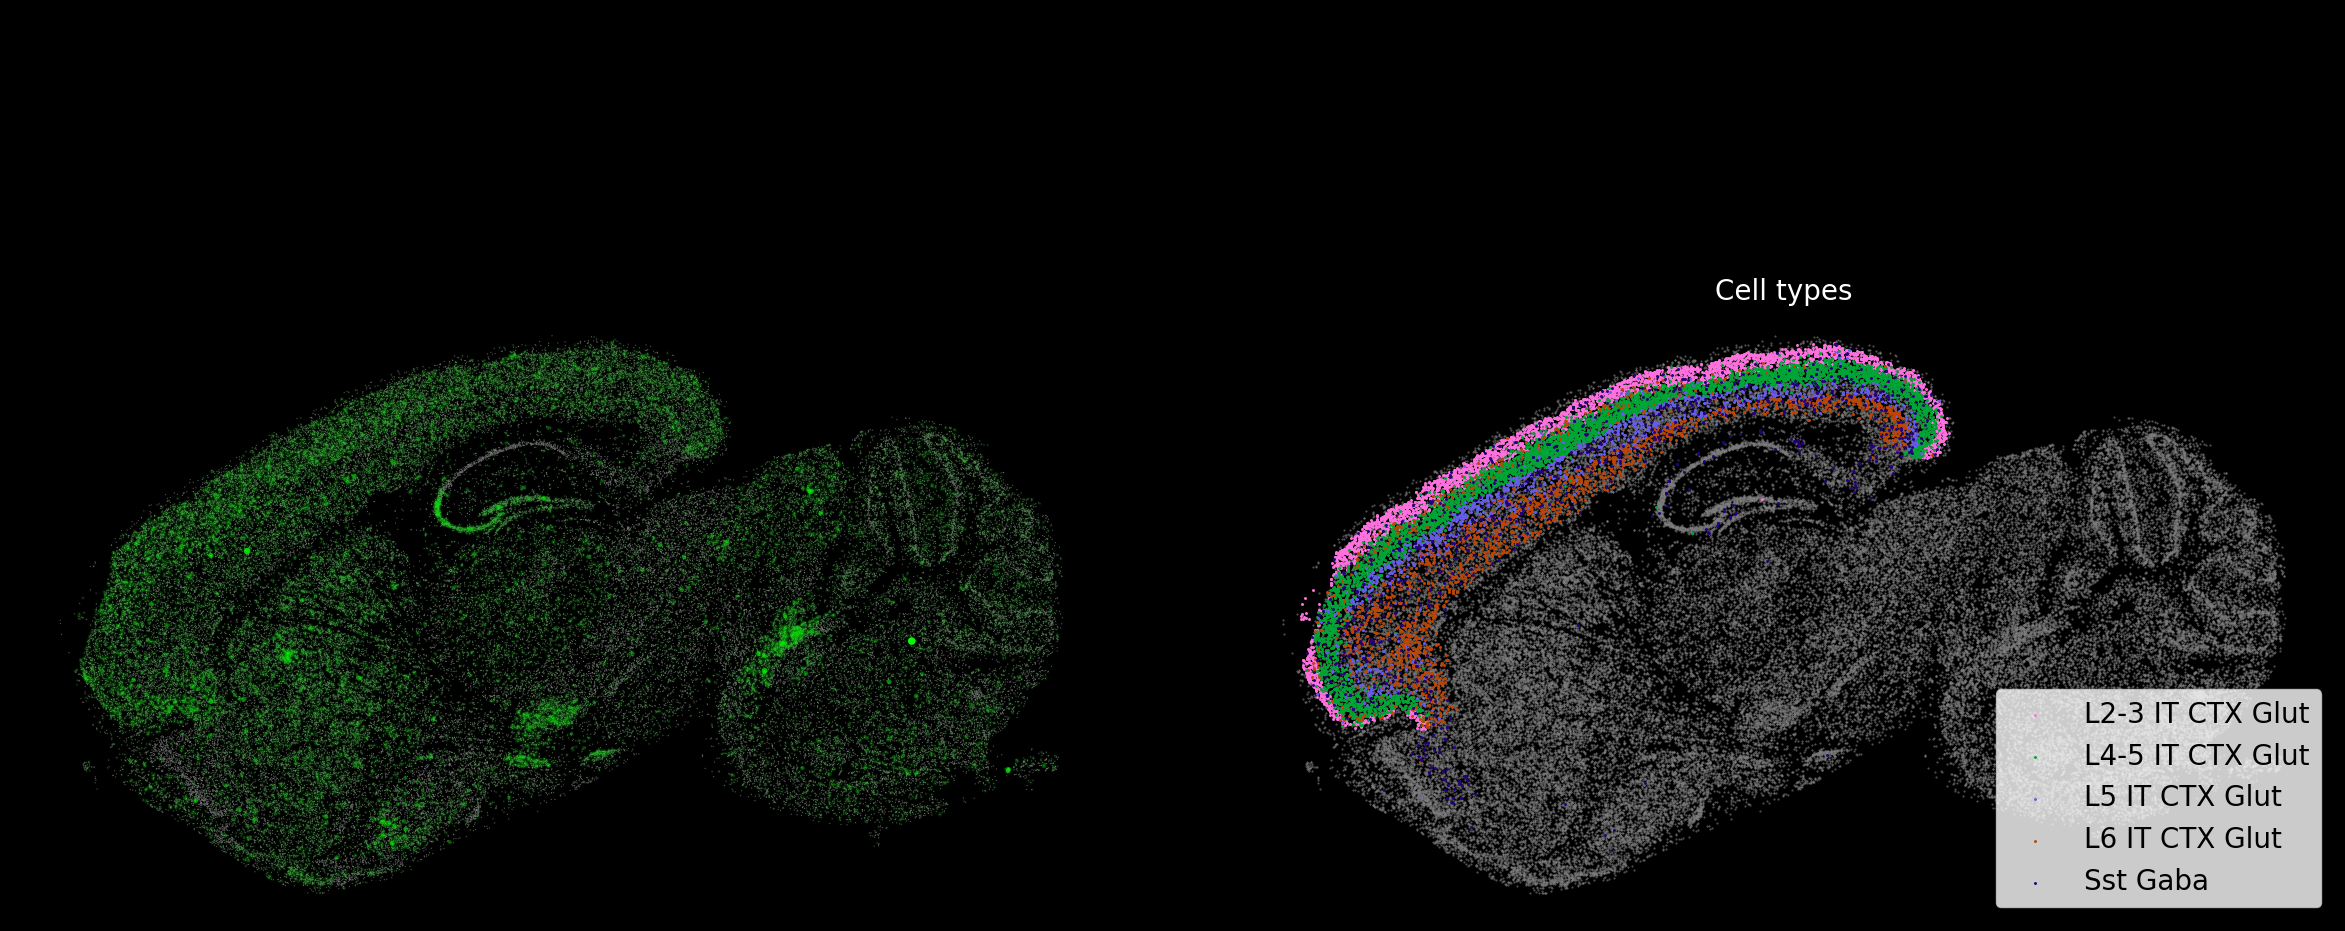

In [351]:
from utils import STARRFISH

cre = 'CRE235'

# rank by q-value
cre_q_values = res2['qvalue_activity'].loc[cell_types_to_use_nc_2, cre]
cre_q_values = cre_q_values[cre_q_values <= 0.05] 
# order by rank
cre_q_values = cre_q_values.sort_values(ascending=True)
cell_types_to_visualize = cre_q_values.index

fig = plot_all_cres(starrfish2_filtered,
    cre, average_by_celltype=False, # if true, all cells from same cell type will have same value
    norm_by_negative_control_cell_type_sum=False, # normalize raw counts by the sum of negative control in the cell type
    norm_by_negative_control_cell_type_mean=False, # normalize raw counts by the mean of negative control in the cell type
    norm_by_negative_control_single_cell=False, # normalize raw counts by the negative control in each single cell
    cell_types_to_visualize=cell_types_to_visualize, # only visualize some cell types
    scale_size_by='counts', # scale size by "counts": normalized counts; or "celltype_number": number of cells in the cell type
    log=False, transpose=-1, flipx=-1, sz_min=10,sz_max=30, nmax=None,
    cell_types_to_use=cell_types_to_use_nc_2, show_title=False, show_scale_bar=False)

fig
# fig.savefig(rf'C:\Users\zgibbs\STARR-FISH\figures\STARR-FISH_ms_figure_3\CRE_activity_spatial_plots\all_cres.pdf')
# fig.savefig(rf'C:\Users\zgibbs\STARR-FISH\figures\STARR-FISH_ms_figure_3\CRE_activity_spatial_plots\all_cres.png', dpi=500)